<a href="https://colab.research.google.com/github/YAshhh29/Algorithms/blob/main/Decision_Tree(Basic_Titanic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Data Preparation
In this step, we use `pandas` and `seaborn` to prepare our raw data for the machine learning model.

**Step-by-Step Breakdown:**
1. **Feature Selection**: We select `pclass`, `sex`, `age`, and `fare`. These are our 'Independent Variables' ($X$).
2. **Handling Missing Values**: We use `fillna()` with the median. This is better than deleting rows, as it preserves the dataset size.
3. **Label Encoding**: Machines can't calculate 'male' times 2. We map these to 0 and 1 so the model can use them in mathematical equations.
4. **Train/Test Split**: We use a `random_state` to ensure that every student gets the same 'random' split for consistent results.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

columns_to_keep = ['survived', 'pclass', 'sex', 'age', 'fare']
df = df[columns_to_keep]

df['age'] = df['age'].fillna(df['age'].median())

df['sex'] = df['sex'].map({'female': 0, 'male': 1})

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessing complete. Ready to train!")
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Data preprocessing complete. Ready to train!
Training samples: 712, Testing samples: 179


# Part 2: Understanding Overfitting
Here we train a `DecisionTreeClassifier` with no depth limit.

**What is Gini Impurity?**
In each node, the tree calculates a 'Gini' score. A score of 0.0 means the node is 'pure' (everyone either died or survived). A score of 0.5 means it's a 50/50 split. The tree makes splits that reduce this impurity the most.

**The Overfitting Trap:**
Notice that the training accuracy is nearly 100%, but testing is much lower. The tree has 'memorized' specific passengers (e.g., 'A 22-year-old male who paid 7.25 always dies') rather than learning general rules.

In [ ]:
unrestricted_tree = DecisionTreeClassifier(random_state=42)

unrestricted_tree.fit(X_train, y_train)

train_preds = unrestricted_tree.predict(X_train)
test_preds = unrestricted_tree.predict(X_test)

print("--- Unrestricted Decision Tree ---")
print(f"Training Accuracy: {accuracy_score(y_train, train_preds):.2f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, test_preds):.2f}")
print(f"Tree Depth: {unrestricted_tree.get_depth()} layers deep")

--- Unrestricted Decision Tree ---
Training Accuracy: 0.98
Testing Accuracy:  0.75
Tree Depth: 21 layers deep


# Part 3: Visualizing the Decision Logic
By limiting `max_depth=3`, we force the model to find the most important 'big picture' rules.

**How to read the tree:**
- **Root Node**: The very first question asked.
- **Samples**: How many passengers are in that specific bucket.
- **Value**: The count of [Died, Survived] in that node.

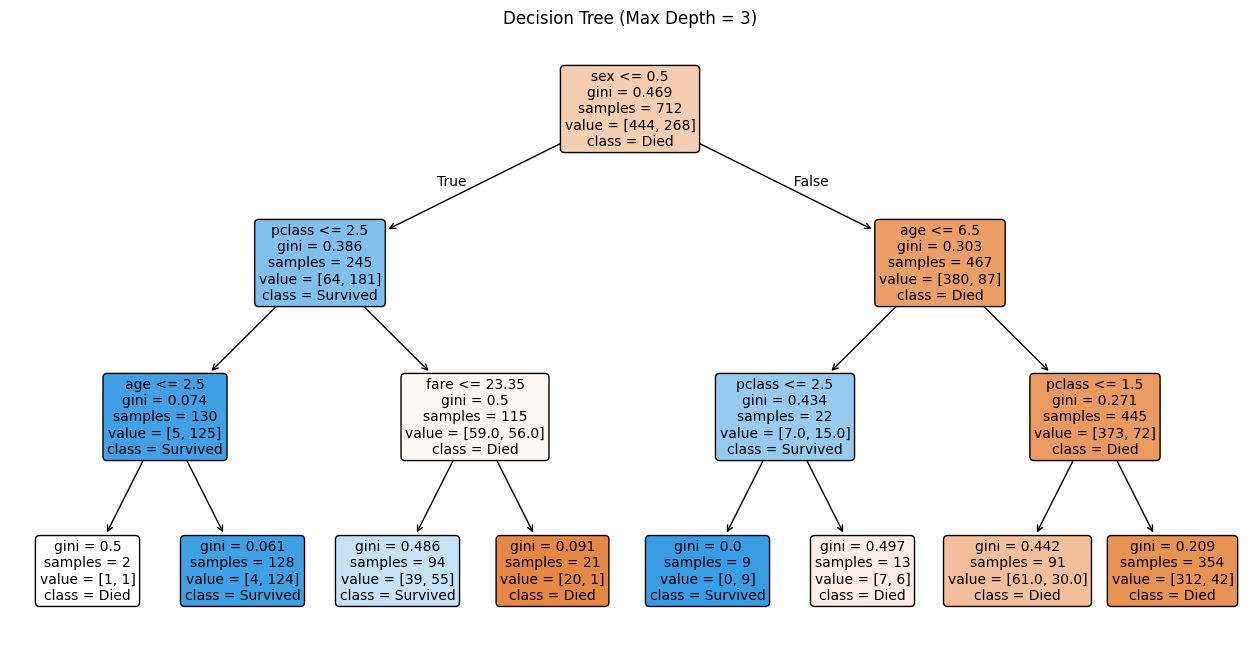

In [ ]:
visual_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
visual_tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(visual_tree,
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (Max Depth = 3)")
plt.show()

# Part 4: Random Forest — Ensemble Learning
A Random Forest is a 'Forest' of many decision trees.

**Why is it better?**
It uses **Bagging** (Bootstrap Aggregating). Each tree is trained on a random sample of the data. When it's time to predict, all 100 trees 'vote.' This 'Wisdom of the Crowd' cancels out the individual errors and overfitting of single trees.

In [ ]:
forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

forest.fit(X_train, y_train)

rf_train_preds = forest.predict(X_train)
rf_test_preds = forest.predict(X_test)

print("--- Random Forest (100 Trees) ---")
print(f"Training Accuracy: {accuracy_score(y_train, rf_train_preds):.2f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, rf_test_preds):.2f}")

--- Random Forest (100 Trees) ---
Training Accuracy: 0.98
Testing Accuracy:  0.80


# Part 5: Feature Importance
Which features mattered most? The model tracks which variables reduced the **Gini Impurity** the most across all 100 trees.

**Teaching Tip**: Ask students why 'Sex' and 'Fare' are so high. This often correlates with the 'Women and Children first' rule and the location of cabins (Class) on the ship.

/tmp/ipykernel_3059/2322759178.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


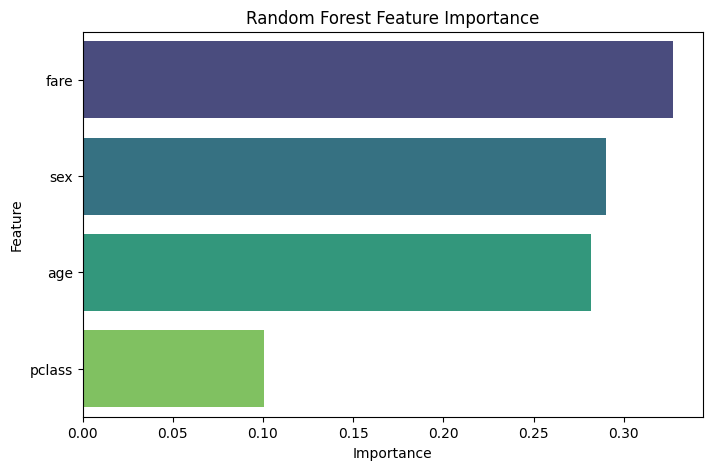

In [ ]:
importances = forest.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Part 6: Deep Dive into Evaluation Metrics
Accuracy isn't enough. We must use the **Confusion Matrix**:

1. **Precision**: 'Of all the people I *guessed* survived, how many actually did?' (Low Precision = many False Positives).
2. **Recall**: 'Of all the people who *actually* survived, how many did I find?' (Low Recall = many False Negatives).
3. **F1-Score**: The balance between the two.

**The Matrix Layout:**
- Top Left: Correct Deaths (TN)
- Bottom Right: Correct Survivals (TP)
- Off-diagonals: The model's mistakes.

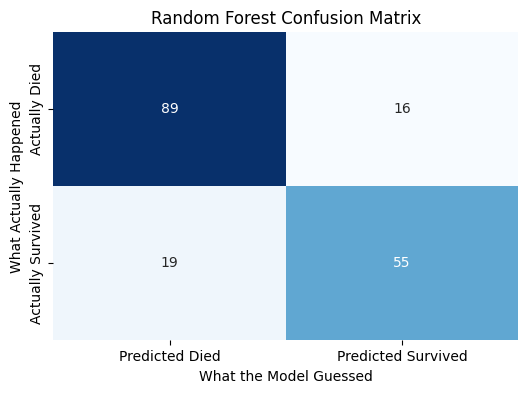


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Died       0.82      0.85      0.84       105
    Survived       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, rf_test_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actually Died', 'Actually Survived'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('What the Model Guessed')
plt.ylabel('What Actually Happened')
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, rf_test_preds, target_names=['Died', 'Survived']))

# Part 7: Optimization via Cross-Validation
**How Cross-Validation (CV) Works:**
Instead of one test, we do 'K-Folds' (here, $K=3$):
- Split data into 3 parts (A, B, C).
- Round 1: Train on A+B, test on C.
- Round 2: Train on A+C, test on B.
- Round 3: Train on B+C, test on A.
- **Result**: The average of these three scores. This ensures the model isn't just 'lucky' with one specific split.

**Grid Search**: This automates the process of trying every combination of `n_estimators` and `max_depth` to find the 'Goldilocks' settings for our forest.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=1)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best Training Accuracy from Grid Search: {grid_search.best_score_:.2f}")

best_rf = grid_search.best_estimator_
tuned_test_preds = best_rf.predict(X_test)
print(f"Tuned Model Testing Accuracy: {accuracy_score(y_test, tuned_test_preds):.2f}")

Starting Grid Search...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters Found: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best Training Accuracy from Grid Search: 0.83
Tuned Model Testing Accuracy: 0.82
